In [15]:
# main.py
import os
from utils.data_preprocessing import fq_pie_pre_process_extract, dualpi2_pre_process_extract, trim_df
from utils.utils import get_stats, find_files_with_extension, extract_unique_mbps_and_ms
import pandas as pd

In [16]:
columns_to_use = [
    'queue_type', 'burst_allowance', 'drop_probability', 'current_queue_delay',
    'accumulated_probability', 'average_dequeue_time', 'length_in_bytes', 'total_drops', 'packet_length'
]

In [17]:
folderpaths = ['../../data/udp_data_2025-04-29/kernel_data']

In [18]:
filenames, filepaths, filedict = find_files_with_extension(paths=folderpaths, extension='.txt')

In [19]:
# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')

unique_scenarios_dict_v2 = {}
for mbps, ms in unique_combinations:
    scenario_search = f"{mbps}Mbps_{ms}ms"
    for index in range(len(filenames)):
        if scenario_search in filenames[index]:
            print(f"Found {scenario_search} in {filenames[index]}")
            if scenario_search in unique_scenarios_dict_v2:
                unique_scenarios_dict_v2[scenario_search].append(filedict[filenames[index]])
            else:
                unique_scenarios_dict_v2[scenario_search]=[filedict[filenames[index]]]
            


Unique Mbps and ms Combinations:
8 Mbps, 10 ms
Found 8Mbps_10ms in kernel_data_1_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in kernel_data_2_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in kernel_data_3_dualpi2_8Mbps_10ms_ecn_udp.txt


In [20]:
# dualpi2_df['queue_type'].value_counts().sort_index(ascending=True).plot(kind='bar', title='queue_type')
# dualpi2_df['burst_allowance'].value_counts().sort_index(ascending=True).plot(kind='bar', title='Burst Allowance')

In [21]:
import matplotlib.pyplot as plt

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    dualpi2_df.to_csv("temp.csv")

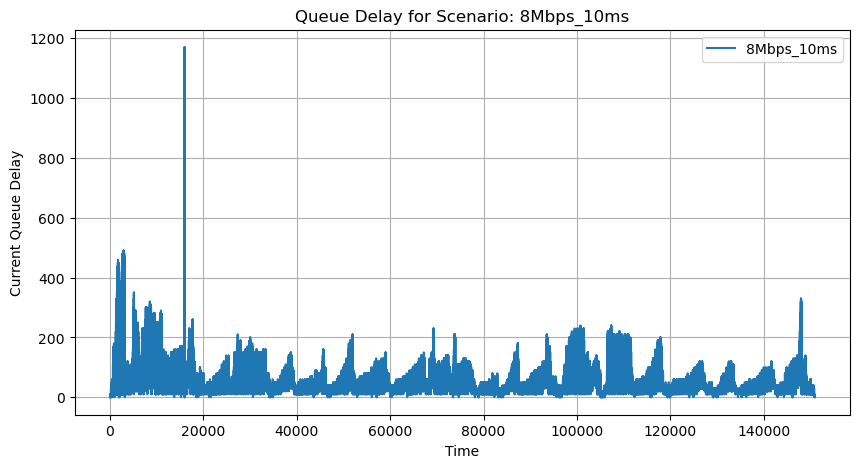

In [7]:
import matplotlib.pyplot as plt

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    
    # Plot 'current_queue_delay' vs index
    plt.figure(figsize=(10, 5))
    plt.plot(dualpi2_df.index, dualpi2_df['current_queue_delay']/1000, label=scenario)
    plt.title(f'Queue Delay for Scenario: {scenario}')
    plt.xlabel('Time')
    plt.ylabel('Current Queue Delay')
    plt.legend()
    plt.grid(True)
    plt.show()


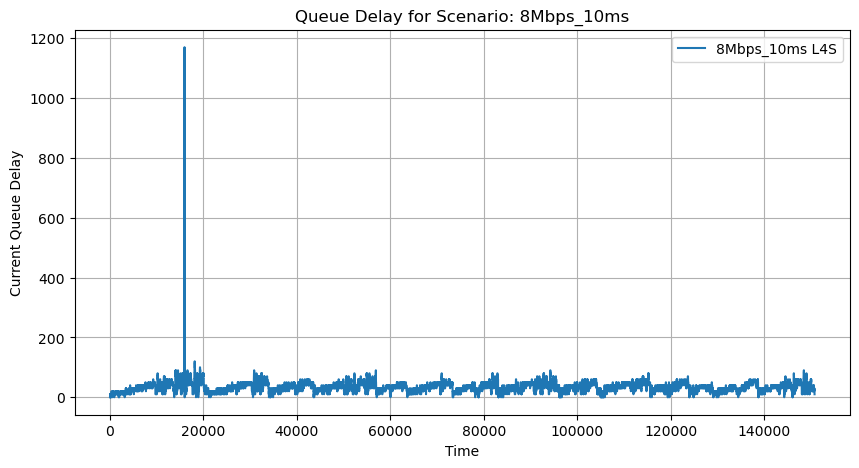

In [8]:
import matplotlib.pyplot as plt

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    ldf = dualpi2_df[dualpi2_df['queue_type'] == 1]
    
    # Plot 'current_queue_delay' vs index
    plt.figure(figsize=(10, 5))
    plt.plot(ldf.index, ldf['current_queue_delay']/1000, label=scenario+" L4S")
    plt.title(f'Queue Delay for Scenario: {scenario}')
    plt.xlabel('Time')
    plt.ylabel('Current Queue Delay')
    plt.legend()
    plt.grid(True)
    plt.show()


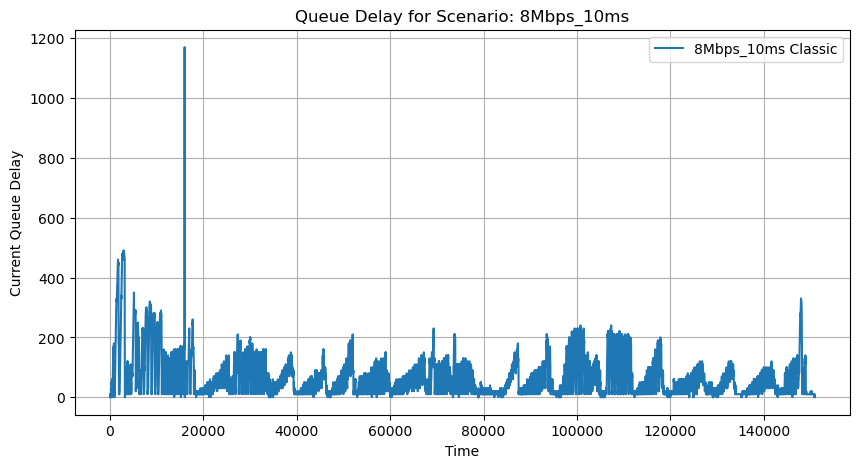

In [9]:
import matplotlib.pyplot as plt

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    cdf = dualpi2_df[dualpi2_df['queue_type'] == 0]
    
    # Plot 'current_queue_delay' vs index
    plt.figure(figsize=(10, 5))
    plt.plot(cdf.index, cdf['current_queue_delay']/1000, label=scenario+" Classic")
    plt.title(f'Queue Delay for Scenario: {scenario}')
    plt.xlabel('Time')
    plt.ylabel('Current Queue Delay')
    plt.legend()
    plt.grid(True)
    plt.show()


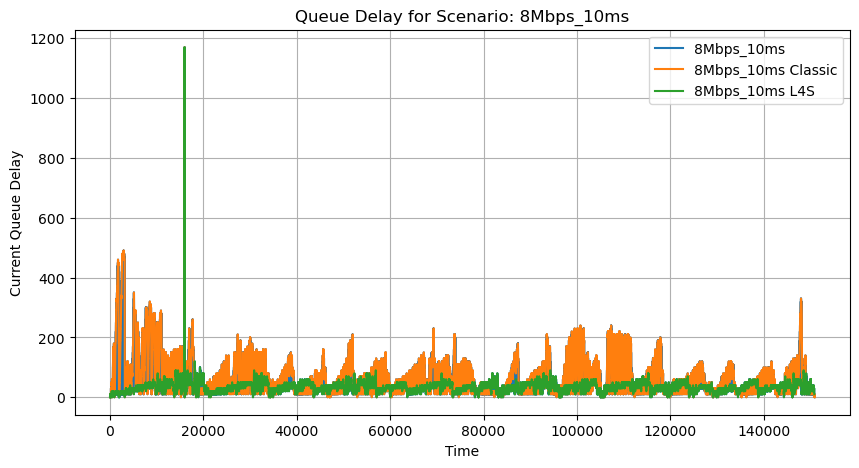

In [10]:
import matplotlib.pyplot as plt

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    cdf = dualpi2_df[dualpi2_df['queue_type'] == 0]
    ldf = dualpi2_df[dualpi2_df['queue_type'] == 1]
    
    # Plot 'current_queue_delay' vs index
    plt.figure(figsize=(10, 5))
    plt.plot(dualpi2_df.index, dualpi2_df['current_queue_delay']/1000, label=scenario)
    plt.plot(cdf.index, cdf['current_queue_delay']/1000, label=scenario+" Classic")
    plt.plot(ldf.index, ldf['current_queue_delay']/1000, label=scenario+" L4S")
    plt.title(f'Queue Delay for Scenario: {scenario}')
    plt.xlabel('Time')
    plt.ylabel('Current Queue Delay')
    plt.legend()
    plt.grid(True)
    plt.show()


In [11]:
# Initialize an empty list to store the results
results = []

for scenario in unique_scenarios_dict_v2.keys():
    filepath = unique_scenarios_dict_v2[scenario][0]
    
    # Preprocess and extract data from the file
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath, aqm='dualpi2')
    
    # Calculate the means for the different queue types
    overallqd_mean = dualpi2_df['current_queue_delay'].mean()
    cqd_mean = dualpi2_df[dualpi2_df['queue_type'] == 0]['current_queue_delay'].mean()
    lqd_mean = dualpi2_df[dualpi2_df['queue_type'] == 1]['current_queue_delay'].mean()

    # Extract the value counts for dequeue_action and queue_type as strings
    dequeue_action_counts = dualpi2_df['dequeue_action'].value_counts().to_dict()
    queue_type_counts = dualpi2_df['queue_type'].value_counts().to_dict()
    
    # Convert the value counts to strings to easily add to the dataframe
    dequeue_action_str = str(dequeue_action_counts)
    queue_type_str = str(queue_type_counts)

    # Append the means, value counts, and filepath to the results list
    results.append({
        'scenario': scenario,
        'overallqd_mean': overallqd_mean,
        'cqd_mean': cqd_mean,
        'lqd_mean': lqd_mean,
        'dequeue_action_counts': dequeue_action_str,
        'queue_type_counts': queue_type_str
    })

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Print the dataframe
print(results_df)

# Convert mean values from ms to seconds (divide by 1000)
results_df['overallqd_mean'] = results_df['overallqd_mean'] / 1000
results_df['cqd_mean'] = results_df['cqd_mean'] / 1000
results_df['lqd_mean'] = results_df['lqd_mean'] / 1000

# Function to extract bandwidth and delay from the scenario column
def extract_bandwidth_delay(scenario):
    bandwidth, delay = scenario.split('_')
    bandwidth_value = int(bandwidth.replace('Mbps', ''))
    delay_value = int(delay.replace('ms', ''))
    return bandwidth_value, delay_value

# Extract bandwidth and delay values
results_df[['bandwidth', 'delay']] = results_df['scenario'].apply(extract_bandwidth_delay).apply(pd.Series)

# Sort first by bandwidth, then by delay
df_sorted = results_df.sort_values(by=['bandwidth', 'delay'])


# Save the sorted dataframe to a CSV file
df_sorted.to_csv('kernel_queue_delay_results.csv', index=False)

df_sorted = results_df.sort_values(by=['overallqd_mean'])
df_sorted.to_csv('kernel_queue_delay_results_sorted_ascending.csv', index=False)


     scenario  overallqd_mean      cqd_mean      lqd_mean  \
0  8Mbps_10ms     38641.48592  56443.286297  32069.015593   

          dequeue_action_counts      queue_type_counts  
0  {0: 149219, 1: 1020, 2: 617}  {1: 110178, 0: 40678}  


In [12]:
for filepath in filepaths:
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath,aqm='dualpi2')
    overallqd_mean = dualpi2_df['current_queue_delay'].mean()
    cqd_mean = dualpi2_df[dualpi2_df['queue_type'] == 0]['current_queue_delay'].mean()
    lqd_mean = dualpi2_df[dualpi2_df['queue_type'] == 1]['current_queue_delay'].mean()

    if cqd_mean < lqd_mean:
        print("L4S Queue Delay is greater than Classic Queue Delay")
    
        
        print()
        print("*** Start ***"*3)
        print(filepath)
        print("dequeu_actions",dualpi2_df['dequeue_action'].value_counts())
        print("queue_type",dualpi2_df['queue_type'].value_counts())
        print("Classic Queue: ",dualpi2_df[dualpi2_df['queue_type'] == 0]['current_queue_delay'].mean())
        print("L4S Queue: ",dualpi2_df[dualpi2_df['queue_type'] == 1]['current_queue_delay'].mean())

    


In [13]:
for filepath in filepaths:
    
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath,aqm='dualpi2')

    if dualpi2_df['current_queue_delay'].mean() < 10000:
        print()
        print("*** Start ***"*3)
        print(filepath)
        print("dequeu_actions",dualpi2_df['dequeue_action'].value_counts())
        print("queue_type",dualpi2_df['queue_type'].value_counts())
        print("Classic Queue Stats")
        get_stats(dualpi2_df[dualpi2_df['queue_type'] == 0], columns_to_use[3])
        print("L4S Queue Stats")
        get_stats(dualpi2_df[dualpi2_df['queue_type'] == 1], columns_to_use[3])
        # get_stats(dualpi2_df, columns_to_use[3])
        print()
        print("*** END ***"*3)
    


In [14]:
for filepath in filepaths:
    
    dualpi2_df = dualpi2_pre_process_extract(input_file=filepath,aqm='dualpi2')

    if dualpi2_df['current_queue_delay'].mean() < 10000 and len(dualpi2_df['dequeue_action'].unique()) > 1:
        print()
        print("*** Start ***"*3)
        print(filepath)
        print("dequeu_actions",dualpi2_df['dequeue_action'].value_counts())
        print("queue_type",dualpi2_df['queue_type'].value_counts())
        get_stats(dualpi2_df[dualpi2_df['queue_type'] == 0], columns_to_use[3])
        get_stats(dualpi2_df[dualpi2_df['queue_type'] == 1], columns_to_use[3])
        # get_stats(dualpi2_df, columns_to_use[3])
        print()
        print("*** END ***"*3)
    
